# This notebook deals with the question

# **"Can we classify whether the plasma is currently in phase 0 or phase 1?"**

# Logistic Regression

Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedGroupKFold,
    GroupKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

import joblib

Settings

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
FILE_PATH = "/content/drive/MyDrive/Plasma Density Limit Dataset/Open_Density_Limit_Dataset.csv"

RANDOM_STATE = 42

N_OUTER_SPLITS = 5
N_INNER_SPLITS = 4

# Logistic regression hyperparameters
C_VALUES = [
    0.001,
    0.01,
    0.1,
    1.0,
    10.0,
    100.0
]

CLASS_WEIGHTS = [
    None,
    "balanced"
]

Load Data

In [4]:
df = pd.read_csv(FILE_PATH)

print("=" * 70)
print("DATASET")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

DATASET
Shape: (264385, 9)

Columns:
['discharge_ID', 'time', 'density_limit_phase', 'density', 'elongation', 'minor_radius', 'plasma_current', 'toroidal_B_field', 'triangularity']


,discharge_ID,time,density_limit_phase,density,elongation,minor_radius,plasma_current,toroidal_B_field,triangularity
0,1000606012,0.26,0,1.068483,1.596838,0.215675,0.732045,5.375454,0.366888
1,1000606012,0.27,0,1.072965,1.624681,0.214933,0.742422,5.375454,0.379412
2,1000606012,0.28,0,1.077447,1.652525,0.214190,0.752798,5.375454,0.391936
3,1000606012,0.29,0,1.126277,1.662114,0.212518,0.760581,5.375454,0.392512
4,1000606012,0.30,0,1.175108,1.671703,0.210845,0.768363,5.375454,0.393087


Define variables

In [5]:
FEATURES = [
    "density",
    "elongation",
    "minor_radius",
    "plasma_current",
    "toroidal_B_field",
    "triangularity"
]

TARGET = "density_limit_phase"

GROUP = "discharge_ID"

TIME = "time"

Basic Validation

In [6]:
required_columns = FEATURES + [TARGET, GROUP, TIME]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nAll required columns are present.")


All required columns are present.


Clean the data

In [7]:
data = df[required_columns].copy()

# Convert target to numeric
data[TARGET] = pd.to_numeric(
    data[TARGET],
    errors="coerce"
)

# Convert features to numeric
for col in FEATURES:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[TIME] = pd.to_numeric(
    data[TIME],
    errors="coerce"
)

# Remove missing values
before = len(data)

data = data.dropna()

after = len(data)

print(f"\nRows before cleaning: {before}")
print(f"Rows after cleaning : {after}")
print(f"Rows removed        : {before - after}")


Rows before cleaning: 264385
Rows after cleaning : 264385
Rows removed        : 0


Check Target

In [9]:
unique_targets = sorted(
    data[TARGET].unique()
)

print("\nTarget values:", unique_targets)

if not set(unique_targets).issubset({0, 1}):
    raise ValueError(
        "Target contains values other than 0 and 1."
    )

print("\nTarget distribution:")
print(data[TARGET].value_counts())

print("\nTarget proportion:")
print(
    data[TARGET].value_counts(
        normalize=True
    )
)


Target values: [np.int64(0), np.int64(1)]

Target distribution:
density_limit_phase
0    260787
1      3598
Name: count, dtype: int64

Target proportion:
density_limit_phase
0    0.986391
1    0.013609
Name: proportion, dtype: float64


Discharge Level Information

In [10]:
n_discharge = data[GROUP].nunique()

print("\nNumber of discharges:", n_discharge)

# Number of discharges containing both classes
class_per_discharge = (
    data.groupby(GROUP)[TARGET]
    .nunique()
)

print(
    "Discharges containing both classes:",
    (class_per_discharge == 2).sum()
)

print(
    "Discharges containing only one class:",
    (class_per_discharge == 1).sum()
)


Number of discharges: 2333
Discharges containing both classes: 73
Discharges containing only one class: 2260


Features / Target / Group

In [11]:
X = data[FEATURES].copy()

y = data[TARGET].astype(int).copy()

groups = data[GROUP].copy()

Check for Discharge Leakage

In [12]:
print("\n" + "=" * 70)
print("DISCHARGE LEAKAGE CHECK")
print("=" * 70)

# We will demonstrate that every fold keeps complete
# discharges together.

sgkf_check = StratifiedGroupKFold(
    n_splits=N_OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

for fold, (train_idx, test_idx) in enumerate(
    sgkf_check.split(X, y, groups),
    start=1
):

    train_groups = set(
        groups.iloc[train_idx]
    )

    test_groups = set(
        groups.iloc[test_idx]
    )

    overlap = train_groups.intersection(
        test_groups
    )

    print(
        f"Fold {fold}: "
        f"train discharges={len(train_groups)}, "
        f"test discharges={len(test_groups)}, "
        f"overlap={len(overlap)}"
    )

    if overlap:
        raise RuntimeError(
            "DISCHARGE LEAKAGE DETECTED!"
        )

print("\n✓ No discharge leakage.")


DISCHARGE LEAKAGE CHECK
Fold 1: train discharges=1869, test discharges=464, overlap=0
Fold 2: train discharges=1866, test discharges=467, overlap=0
Fold 3: train discharges=1868, test discharges=465, overlap=0
Fold 4: train discharges=1865, test discharges=468, overlap=0
Fold 5: train discharges=1864, test discharges=469, overlap=0

✓ No discharge leakage.


Model

In [13]:
pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "logistic",
        LogisticRegression(
            max_iter=5000,
            solver="lbfgs",
            random_state=RANDOM_STATE
        )
    )
])

Hyperparameter Grid

In [14]:
param_grid = {
    "logistic__C": C_VALUES,
    "logistic__class_weight": CLASS_WEIGHTS
}

Outer CV

In [16]:
outer_cv = StratifiedGroupKFold(
    n_splits=N_OUTER_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

Out-of-Fold Storage

In [17]:
oof_probability = np.full(
    len(data),
    np.nan
)

oof_prediction = np.full(
    len(data),
    np.nan
)

fold_results = []

best_models = []

Nested Cross Validation

In [19]:
# ============================================================
# 15. NESTED CROSS-VALIDATION
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    outer_cv.split(X, y, groups),
    start=1
):

    print("\n" + "-" * 60)
    print(f"OUTER FOLD {fold}")
    print("-" * 60)

    # --------------------------------------------------------
    # Outer training/test split
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

    # --------------------------------------------------------
    # Inner cross-validation
    # --------------------------------------------------------

    inner_cv = StratifiedGroupKFold(
        n_splits=N_INNER_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + fold
    )

    # --------------------------------------------------------
    # Grid search INSIDE the outer fold
    # --------------------------------------------------------

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="average_precision",
        cv=inner_cv,
        n_jobs=-1,
        refit=True
    )

    # IMPORTANT:
    # groups_train is passed to the inner CV
    grid.fit(
        X_train,
        y_train,
        groups=groups_train
    )

    # Best model selected using ONLY the outer
    # training data
    best_model = grid.best_estimator_

    print("Best parameters:")
    print(grid.best_params_)

    print(
        "Best inner PR-AUC:",
        round(grid.best_score_, 4)
    )

    # --------------------------------------------------------
    # Evaluate on completely untouched outer test fold
    # --------------------------------------------------------

    probability = best_model.predict_proba(
        X_test
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    # Store out-of-fold predictions
    oof_probability[test_idx] = probability
    oof_prediction[test_idx] = prediction

    # --------------------------------------------------------
    # Calculate outer-fold metrics
    # --------------------------------------------------------

    fold_auc = roc_auc_score(
        y_test,
        probability
    )

    fold_pr_auc = average_precision_score(
        y_test,
        probability
    )

    fold_accuracy = accuracy_score(
        y_test,
        prediction
    )

    fold_balanced_accuracy = balanced_accuracy_score(
        y_test,
        prediction
    )

    fold_precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    fold_recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    fold_f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        prediction,
        labels=[0, 1]
    ).ravel()

    fold_specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    fold_brier = brier_score_loss(
        y_test,
        probability
    )

    fold_results.append({
        "fold": fold,
        "ROC_AUC": fold_auc,
        "PR_AUC": fold_pr_auc,
        "Accuracy": fold_accuracy,
        "Balanced_Accuracy": fold_balanced_accuracy,
        "Precision": fold_precision,
        "Recall": fold_recall,
        "F1": fold_f1,
        "Specificity": fold_specificity,
        "Brier": fold_brier
    })

    print(f"ROC-AUC          : {fold_auc:.4f}")
    print(f"PR-AUC            : {fold_pr_auc:.4f}")
    print(f"Accuracy          : {fold_accuracy:.4f}")
    print(f"Balanced accuracy : {fold_balanced_accuracy:.4f}")
    print(f"Precision         : {fold_precision:.4f}")
    print(f"Recall            : {fold_recall:.4f}")
    print(f"F1                : {fold_f1:.4f}")
    print(f"Specificity       : {fold_specificity:.4f}")
    print(f"Brier score       : {fold_brier:.4f}")


------------------------------------------------------------
OUTER FOLD 1
------------------------------------------------------------
Best parameters:
{'logistic__C': 10.0, 'logistic__class_weight': None}
Best inner PR-AUC: 0.818
ROC-AUC          : 0.9852
PR-AUC            : 0.8508
Accuracy          : 0.9950
Balanced accuracy : 0.8451
Precision         : 0.9948
Recall            : 0.6902
F1                : 0.8150
Specificity       : 0.9999
Brier score       : 0.0045

------------------------------------------------------------
OUTER FOLD 2
------------------------------------------------------------
Best parameters:
{'logistic__C': 100.0, 'logistic__class_weight': None}
Best inner PR-AUC: 0.8215
ROC-AUC          : 0.9828
PR-AUC            : 0.8571
Accuracy          : 0.9943
Balanced accuracy : 0.8353
Precision         : 0.9968
Recall            : 0.6707
F1                : 0.8018
Specificity       : 1.0000
Brier score       : 0.0049

-------------------------------------------------

Fold Results

In [20]:
fold_results_df = pd.DataFrame(
    fold_results
)

print("\n" + "=" * 70)
print("FOLD RESULTS")
print("=" * 70)

display(fold_results_df)


FOLD RESULTS


,fold,ROC_AUC,PR_AUC,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Specificity,Brier
0,1,0.985192,0.850811,0.995016,0.845067,0.994828,0.690191,0.814972,0.999942,0.004486
1,2,0.982820,0.857128,0.994272,0.835307,0.996769,0.670652,0.801819,0.999962,0.004918
2,3,0.982698,0.807597,0.997071,0.853090,0.918919,0.706697,0.798956,0.999482,0.002864
3,4,0.972837,0.751871,0.994427,0.831886,0.810484,0.665563,0.730909,0.998210,0.004540
4,5,0.982056,0.849381,0.994914,0.835365,0.992647,0.670807,0.800593,0.999923,0.004366


Mean + Std

In [22]:
metric_columns = [
    "ROC_AUC",
    "PR_AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Specificity",
    "Brier"
]

summary = pd.DataFrame({
    "Mean": fold_results_df[metric_columns].mean(),
    "Std": fold_results_df[metric_columns].std()
})

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

display(summary)


CROSS-VALIDATION SUMMARY


,Mean,Std
ROC_AUC,0.981121,0.004781
PR_AUC,0.823358,0.044526
Accuracy,0.995140,0.001124
Balanced_Accuracy,0.840143,0.008750
Precision,0.942729,0.080904
Recall,0.680782,0.017276
F1,0.789450,0.033339
Specificity,0.999504,0.000750
Brier,0.004235,0.000794


Varify OOF Predictions

In [23]:
if np.isnan(oof_probability).any():
    raise RuntimeError(
        "Some samples do not have OOF predictions."
    )

print(
    "\n✓ Every sample has an out-of-fold prediction."
)


✓ Every sample has an out-of-fold prediction.


Global OOF Metrics

In [24]:
oof_probability = oof_probability.astype(float)

oof_prediction = oof_prediction.astype(int)

oof_auc = roc_auc_score(
    y,
    oof_probability
)

oof_pr_auc = average_precision_score(
    y,
    oof_probability
)

oof_accuracy = accuracy_score(
    y,
    oof_prediction
)

oof_balanced_accuracy = balanced_accuracy_score(
    y,
    oof_prediction
)

oof_precision = precision_score(
    y,
    oof_prediction,
    zero_division=0
)

oof_recall = recall_score(
    y,
    oof_prediction,
    zero_division=0
)

oof_f1 = f1_score(
    y,
    oof_prediction,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y,
    oof_prediction,
    labels=[0, 1]
).ravel()

oof_specificity = tn / (tn + fp)

oof_brier = brier_score_loss(
    y,
    oof_probability
)


print("\n" + "=" * 70)
print("GLOBAL OUT-OF-FOLD PERFORMANCE")
print("=" * 70)

print(f"ROC-AUC          : {oof_auc:.4f}")
print(f"PR-AUC            : {oof_pr_auc:.4f}")
print(f"Accuracy          : {oof_accuracy:.4f}")
print(f"Balanced accuracy : {oof_balanced_accuracy:.4f}")
print(f"Precision         : {oof_precision:.4f}")
print(f"Recall            : {oof_recall:.4f}")
print(f"F1                : {oof_f1:.4f}")
print(f"Specificity       : {oof_specificity:.4f}")
print(f"Brier score       : {oof_brier:.4f}")


GLOBAL OUT-OF-FOLD PERFORMANCE
ROC-AUC          : 0.9811
PR-AUC            : 0.8247
Accuracy          : 0.9951
Balanced accuracy : 0.8391
Precision         : 0.9495
Recall            : 0.6787
F1                : 0.7916
Specificity       : 0.9995
Brier score       : 0.0042


OOF Confusion Matrix


OOF confusion matrix:
[[260657    130]
 [  1156   2442]]


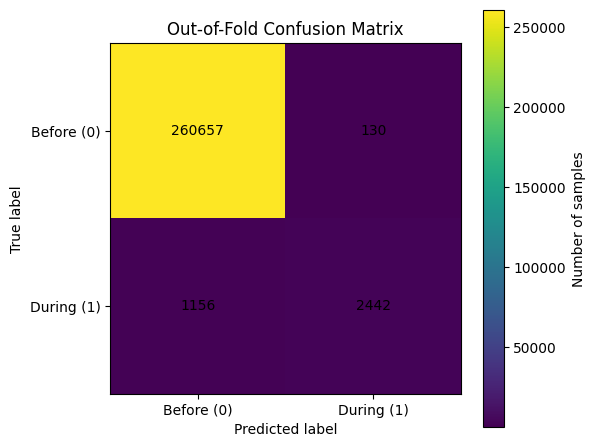

In [26]:
cm = confusion_matrix(
    y,
    oof_prediction
)

print("\nOOF confusion matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

# Add values inside the cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Before (0)",
    "During (1)"
])

ax.set_yticklabels([
    "Before (0)",
    "During (1)"
])

ax.set_title(
    "Out-of-Fold Confusion Matrix"
)

fig.colorbar(
    im,
    ax=ax,
    label="Number of samples"
)

plt.tight_layout()
plt.show()

ROC Curve

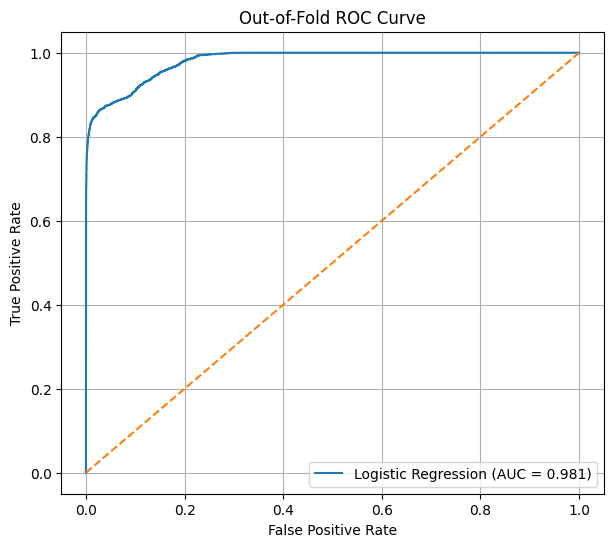

In [27]:
fpr, tpr, roc_thresholds = roc_curve(
    y,
    oof_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {oof_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Out-of-Fold ROC Curve"
)

plt.legend()
plt.grid(True)

plt.show()

Precision-Recall Curve

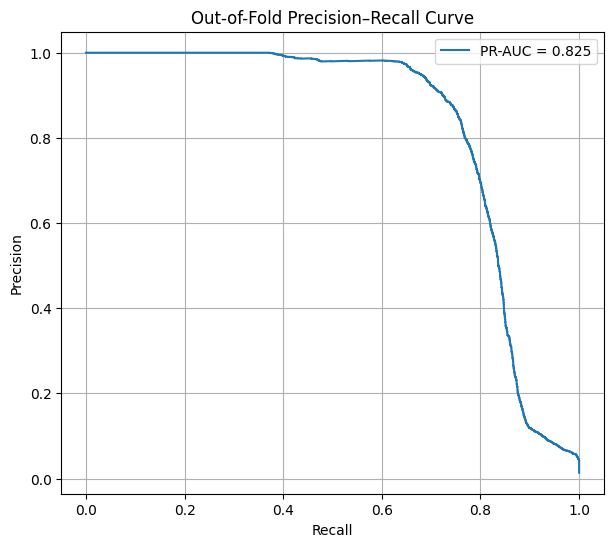

In [28]:
precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y,
        oof_probability
    )
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {oof_pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Out-of-Fold Precision–Recall Curve"
)

plt.legend()
plt.grid(True)

plt.show()

Classification Report

In [30]:
print("\nClassification report:")

print(
    classification_report(
        y,
        oof_prediction,
        target_names=[
            "Before instability (0)",
            "During instability (1)"
        ],
        zero_division=0
    )
)


Classification report:
                        precision    recall  f1-score   support

Before instability (0)       1.00      1.00      1.00    260787
During instability (1)       0.95      0.68      0.79      3598

              accuracy                           1.00    264385
             macro avg       0.97      0.84      0.89    264385
          weighted avg       0.99      1.00      0.99    264385



Calibration

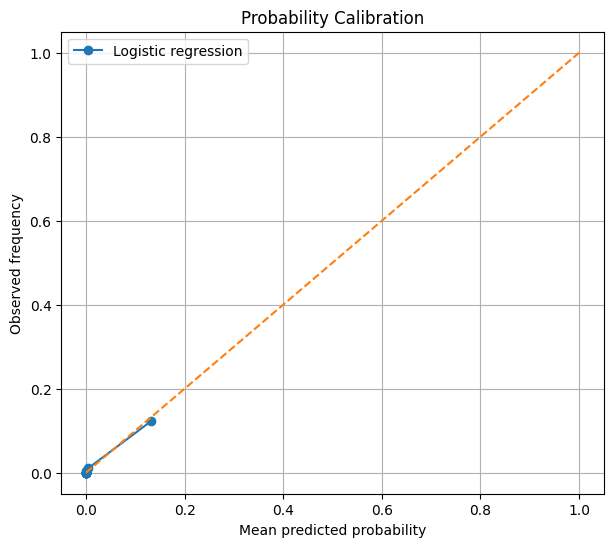

In [31]:
prob_true, prob_pred = calibration_curve(
    y,
    oof_probability,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")

plt.title(
    "Probability Calibration"
)

plt.legend()
plt.grid(True)

plt.show()

Fit Final Model

After the nested CV evaluation is finished, we can fit the final model on ALL available data.

Importantly, this model is NOT used for estimating the cross-validation performance above.

In [32]:
final_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=outer_cv,
    n_jobs=-1,
    refit=True
)

final_grid.fit(
    X,
    y,
    groups=groups
)

final_model = final_grid.best_estimator_

print("\nFinal model parameters:")
print(final_grid.best_params_)


Final model parameters:
{'logistic__C': 100.0, 'logistic__class_weight': None}


Logistic Regression Coefficients

In [33]:
logistic = final_model.named_steps[
    "logistic"
]

coefficients = logistic.coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients),
    "Absolute_Coefficient": np.abs(coefficients)
})

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 70)

display(coefficient_table)


LOGISTIC REGRESSION COEFFICIENTS


,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
3,plasma_current,-3.840862,0.021475,3.840862
0,density,3.007762,20.242043,3.007762
4,toroidal_B_field,1.844885,6.327372,1.844885
2,minor_radius,-0.452719,0.635897,0.452719
1,elongation,-0.317483,0.727979,0.317483
5,triangularity,-0.106246,0.899204,0.106246


Coefficient Plot

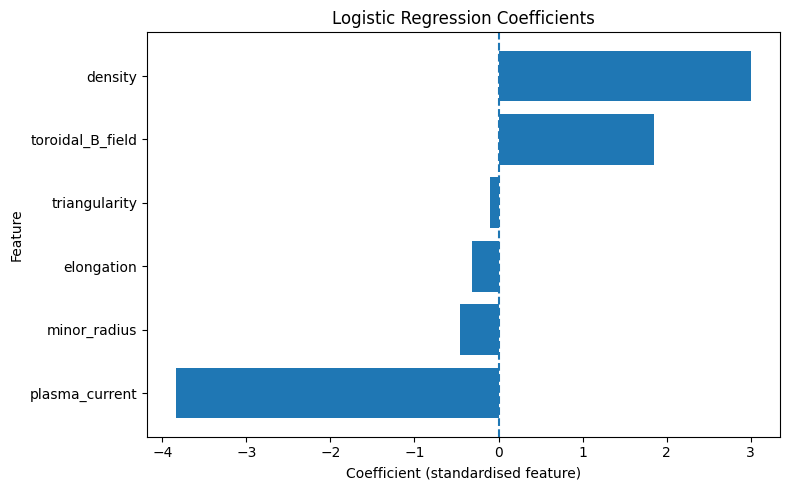

In [34]:
plot_df = (
    coefficient_table
    .sort_values("Coefficient")
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["Feature"],
    plot_df["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Coefficient (standardised feature)"
)

plt.ylabel("Feature")

plt.title(
    "Logistic Regression Coefficients"
)

plt.tight_layout()

plt.show()

Save OOF Results

In [35]:
oof_results = data.copy()

oof_results[
    "predicted_probability"
] = oof_probability

oof_results[
    "predicted_phase"
] = oof_prediction

oof_results.to_csv(
    "/content/density_limit_logistic_oof_predictions.csv",
    index=False
)

print(
    "\nOOF predictions saved."
)


OOF predictions saved.


Save model

In [36]:
joblib.dump(
    final_model,
    "/content/density_limit_logistic_regression.pkl"
)

print(
    "Final model saved."
)

Final model saved.
